In [2]:

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm 
from rpy2.robjects.packages import importr
import rpy2.robjects as robjects

from scipy.stats import shapiro
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score


In [3]:
df18 = pd.read_csv('election_data_2018.csv')

In [4]:
df18.head(5)

,Estado,Municipio,Parroquia,Maduro,Falcon,Bertucci,Quijada,Valid,Invalid,Total
0,Amazonas,Alto Orinoco,Huachamacare,212,78,18,1,309,3,312
1,Amazonas,Alto Orinoco,La Esmeralda,449,75,30,0,554,13,567
2,Amazonas,Alto Orinoco,Marawaka,143,38,0,0,181,2,183
3,Amazonas,Alto Orinoco,Mavaca,616,51,0,0,667,0,667
4,Amazonas,Alto Orinoco,Sierra Parima,380,0,0,0,380,0,380


In [5]:
# Appends data for normality testing based on the candidates' votes as a percentage of valid votes

# Add a new column for the percentage of valid votes won by each candidate
df18["ValidRate"] = df18["Valid"] / df18["Total"]
candidates = ['Maduro','Falcon','Bertucci','Quijada']


# List to store the names of the new columns for the candidates' vote percentages
candidateRates = []

# Calculate the percentage of valid votes for each candidate and add it as a new column
for candidate in candidates:
    csr = candidate + 'SR'
    if candidate not in df18.columns:
        continue
    if csr in df18.columns:
        continue
    df18[csr] = df18[candidate] / df18["Valid"]
    candidateRates.append(candidate + 'SR')


In [6]:
for rate in candidateRates:
    candidate = rate[:-2]  # Remove 'SR' from the column name to get the candidate's name
    stat, pval = shapiro(df18[rate])
    print(f'Shapiro-Wilk test for {candidate}:')
    print(f'Statistic: {stat}, p-value: {pval}\n')
# print(sm.families)

Shapiro-Wilk test for Maduro:
Statistic: 0.9832590822114793, p-value: 3.477193587834194e-10

Shapiro-Wilk test for Falcon:
Statistic: 0.9578215163394718, p-value: 1.2514465459050178e-17

Shapiro-Wilk test for Bertucci:
Statistic: 0.767278988169164, p-value: 2.293578297365784e-37

Shapiro-Wilk test for Quijada:
Statistic: 0.8629299533151503, p-value: 2.044053489438601e-30



Normality of each candidates' support rate confirmed. Testing can proceed.

In [7]:
df18['Winner'] = df18[candidates].idxmax(axis=1)

<Axes: xlabel='MaduroSR', ylabel='ValidRate'>

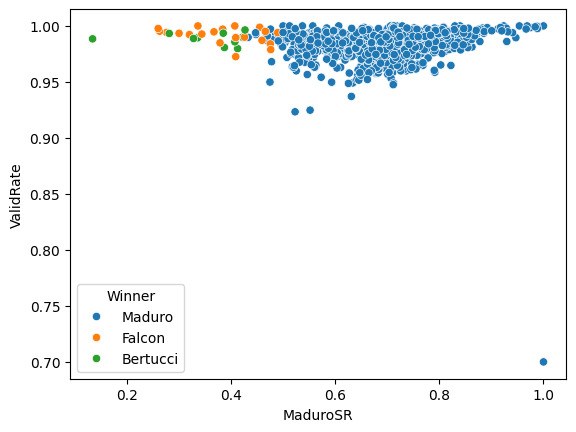

In [8]:
sns.scatterplot(data=df18, x='MaduroSR', y='ValidRate', hue='Winner')

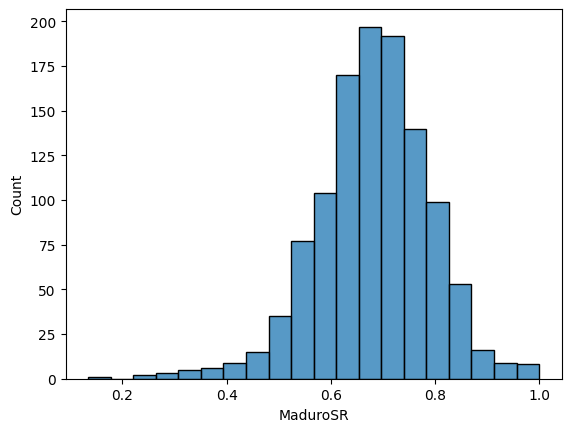

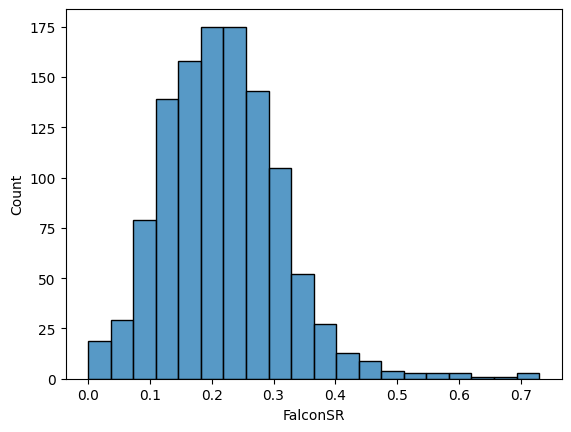

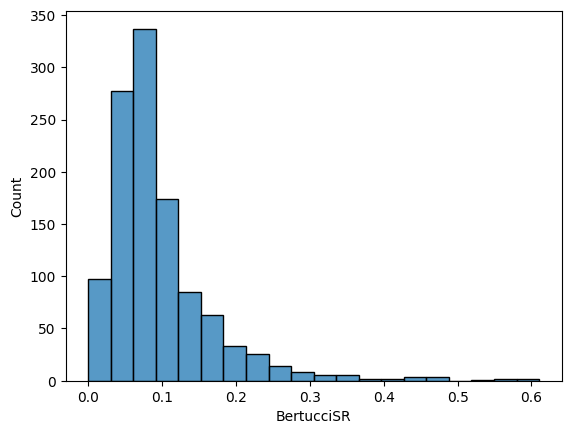

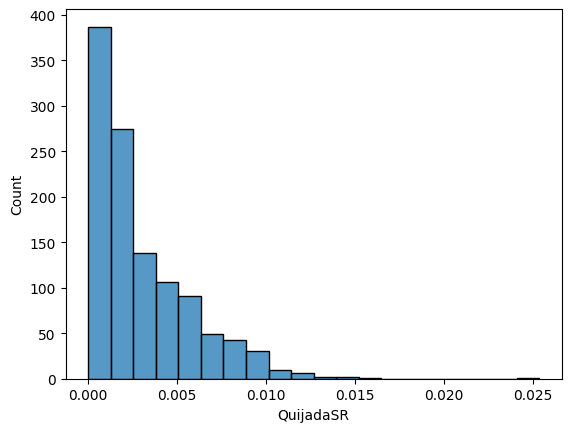

In [9]:
# Plot histograms for the percentage of valid votes for each candidate

for rate in candidateRates:
    plt.figure()
    sns.histplot(df18[rate], bins=20)


In [10]:
# Print outlier rows for validation rate, using statisitical measures

Q1 = df18['ValidRate'].quantile(0.25)
Q3 = df18['ValidRate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df18[(df18['ValidRate'] < lower_bound) | (df18['ValidRate'] > upper_bound)]
print("Outliers in ValidRate:")

Outliers in ValidRate:


No outliers that need be addressed

<Axes: xlabel='ValidRate', ylabel='Count'>

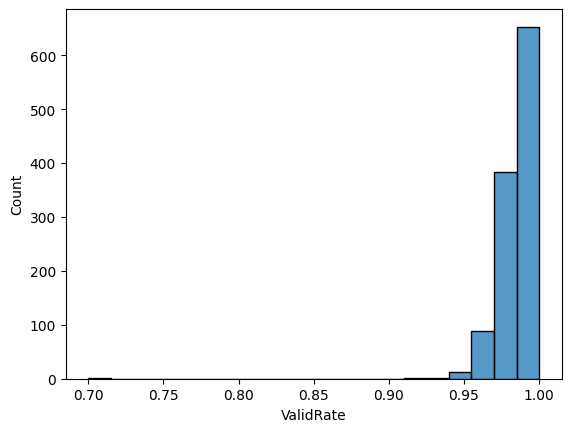

In [11]:
sns.histplot(df18['ValidRate'], bins=20)

In [12]:
# Fit a GLM for each candidate
models = {}
for candidate in candidates:
    csr = candidate + 'SR'
    X = sm.add_constant(df18[csr])
    y = df18['ValidRate']
    model = sm.GLM(y, X, family=sm.families.InverseGaussian()).fit()
    models[candidate] = model

# Display the results

for candidate in candidates:
    print(candidate)
    model = models[candidate]
    print(model.summary())
    print()

Maduro
                 Generalized Linear Model Regression Results                  
Dep. Variable:              ValidRate   No. Observations:                 1141
Model:                            GLM   Df Residuals:                     1139
Model Family:         InverseGaussian   Df Model:                            1
Link Function:         InverseSquared   Scale:                      0.00018297
Method:                          IRLS   Log-Likelihood:                 3218.6
Date:                Mon, 23 Feb 2026   Deviance:                      0.24513
Time:                        20:26:50   Pearson chi2:                    0.208
No. Iterations:                     5   Pseudo R-squ. (CS):           0.003023
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0416      0.005    198.809  

In [13]:

X = sm.add_constant(df18[candidateRates])
y = df18['ValidRate']
model = sm.GLM(y, X, family=sm.families.Gaussian()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              ValidRate   No. Observations:                 1141
Model:                            GLM   Df Residuals:                     1137
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                      0.00015252
Method:                          IRLS   Log-Likelihood:                 3396.7
Date:                Mon, 23 Feb 2026   Deviance:                      0.17341
Time:                        20:26:50   Pearson chi2:                    0.173
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1411
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4727      0.026     18.214      0.000       0.422       0.524
MaduroSR       0.5168      0.026     19.695      0.000       0.465       0.568
FalconSR       0.5043      0.027     19.024      0.000       0.452       0.556
BertucciSR     0.5415      0.028     19.675      0.000       0.488       0.595
QuijadaSR     -1.0899      0.106    -10.306      0.000      -1.297      -0.883
==============================================================================
"""

In [21]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import rpy2.robjects.packages as rpackages

# Import R's 'utils' package to handle installations
utils = importr('utils')

# Select a mirror and install VGAM
utils.chooseCRANmirror(ind=1) # Selects the first available mirror
utils.install_packages('VGAM')
vgam = importr('VGAM')

# Use the localconverter context to safely transform your pandas DataFrame (df18)
with localconverter(robjects.default_converter + pandas2ri.converter):
    r_data = robjects.conversion.py2rpy(df18)

# Verification
print(f"R object type: {type(r_data)}")
print(f"Column names: {r_data.names}")


R callback write-console: trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/VGAM_1.1-14.tgz'
  
R callback write-console: Content type 'application/x-gzip'  
R callback write-console:  length 8137070 bytes (7.8 MB)
  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R cal


The downloaded binary packages are in
	/var/folders/sl/4g_r_0yn3lj90f8gs0fxhkwm0000gn/T//RtmpSXmbHc/downloaded_packages
R object type: <class 'rpy2.robjects.vectors.DataFrame'>
Column names:  [1] "Estado"     "Municipio"  "Parroquia"  "Maduro"     "Falcon"    
 [6] "Bertucci"   "Quijada"    "Valid"      "Invalid"    "Total"     
[11] "ValidRate"  "MaduroSR"   "FalconSR"   "BertucciSR" "QuijadaSR" 
[16] "Winner"    



In [22]:
robjects.globalenv['r_data'] = r_data


# Load the VGAM package
VGAM = importr('VGAM')

# R code
rCodeFit = ('''
library(VGAM)
fit <- vglm(cbind(Valid, Invalid) ~ MaduroSR, betabinomial, data = r_data)
print(summary(fit))
''')

rCodePredict = '''
predicted <- predict(fit, type = "response")
predicted
'''


In [23]:
summary = robjects.r(rCodeFit)
predicted = robjects.r(rCodePredict)



Call:
vglm(formula = cbind(Valid, Invalid) ~ MaduroSR, family = betabinomial, 
    data = r_data)

Coefficients: 
              Estimate Std. Error  z value Pr(>|z|)    
(Intercept):1  3.50749    0.11165   31.414  < 2e-16 ***
(Intercept):2 -5.14113    0.04718 -108.959  < 2e-16 ***
MaduroSR       0.92702    0.16382    5.659 1.52e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Names of linear predictors: logitlink(mu), logitlink(rho)

Log-likelihood: -5602.328 on 2279 degrees of freedom

Number of Fisher scoring iterations: 7 



P value <0.05 indicates we should reject, the null, that differential invalidation was not used in favor of winning candidate. Alternative hypothesis is looking for a positive slope, which would indicate vote invalidation in favor of the winning candidate. Thus, there is statistically significant evidence that differential invalidation was used in favor of winning candidate. Indicates further investigation should be pursued.

In [24]:
df18['MaduroPredicted'] = np.array(predicted) * 100

In [26]:
pltdf = df18.sort_values('Total', ascending=True)
pltdf.head(5)

,Estado,Municipio,Parroquia,Maduro,Falcon,Bertucci,Quijada,Valid,Invalid,Total,ValidRate,MaduroSR,FalconSR,BertucciSR,QuijadaSR,Winner,MaduroPredicted
26,Amazonas,Rio Negro,Cocuy,11,11,0,0,22,0,22,1.000000,0.500000,0.500000,0.000000,0.0,Maduro,98.149435
22,Amazonas,Maroa,Comunidad,34,14,0,0,48,0,48,1.000000,0.708333,0.291667,0.000000,0.0,Maduro,98.469464
5,Amazonas,Atabapo,Caname,66,4,1,0,71,1,72,0.986111,0.929577,0.056338,0.014085,0.0,Maduro,98.749726
25,Amazonas,Rio Negro,Casiquiare,70,0,0,0,70,30,100,0.700000,1.000000,0.000000,0.000000,0.0,Maduro,98.827814
899,Tachira,Sucre,Eleazar Lopez Contrera,44,64,0,0,108,0,108,1.000000,0.407407,0.592593,0.000000,0.0,Falcon,97.986915


/Users/james/.pyenv/versions/3.11.8/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


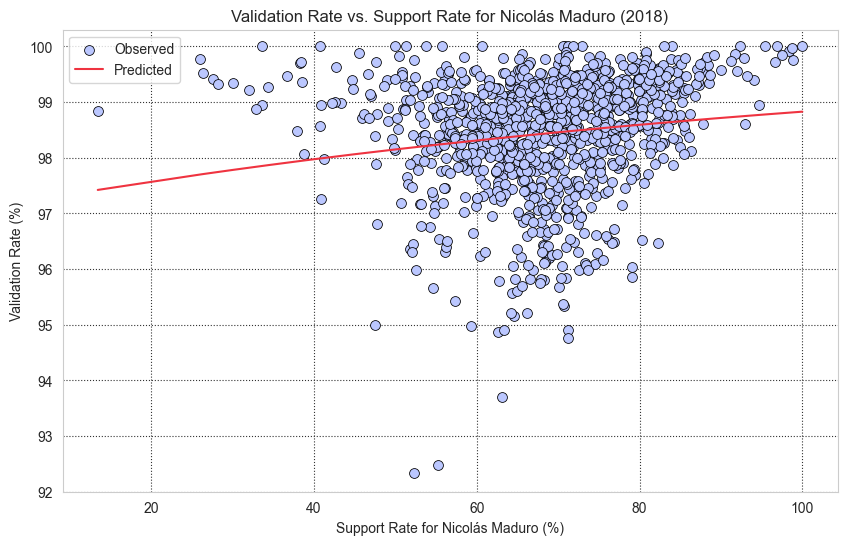

In [27]:
red = (0.9372549019607843, 0.2, 0.25098039215686274)
norm = Normalize(df18['ValidRate'].min(), df18['ValidRate'].max())
blue = (0, 0.1411764705882353, 0.49019607843137253)

x = 225
minblue = (165/x, 176/x, 1)

norm = LogNorm(vmin = 10, vmax = 150000)
blues_cmap = LinearSegmentedColormap.from_list("custom_blues", [minblue, blue])

pltdf["ValidPercent"] = df18["ValidRate"] * 100
pltdf["MaduroPercent"] = df18["MaduroSR"] * 100

# Plot the data and the regression line
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {"grid.color": ".2", "grid.linestyle": ":"})
sns.scatterplot(x='MaduroPercent', y='ValidPercent', label = 'Observed', data=pltdf, color = minblue, edgecolor = 'black', s=50, norm = norm, legend = False) 
sns.lineplot(x='MaduroPercent', y='MaduroPredicted', data=pltdf, color = red, label='Predicted')
plt.xlabel('Support Rate for Nicolás Maduro (%)')
plt.ylabel('Validation Rate (%)')
plt.title('Validation Rate vs. Support Rate for Nicolás Maduro (2018)')
plt.ylim(92, 100.3)

# Show the plot
plt.show()
